<a href="https://colab.research.google.com/github/KhaledMahaMudRajon/LinearRegressionForAI-ML/blob/main/220110.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load and Explore the Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data (adjust path after mounting Google Drive)
df = pd.read_csv('/content/drive/MyDrive/melb_data.csv')
print(df.shape)
df.head()

(13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


Data Preprocessing (Cleaning):Handle missing values

In [2]:
# Drop rows where target is missing
df.dropna(subset=['Price'], inplace=True)

# Fill missing numerical columns with median
num_cols = ['Landsize', 'BuildingArea', 'YearBuilt', 'Car']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Drop columns with too many missing or irrelevant info (e.g., Address, SellerG, Date, CouncilArea? Keep for later but not for regression)
# We'll keep only relevant features for prediction
features = ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
            'YearBuilt', 'Distance', 'Lattitude', 'Longtitude', 'Propertycount']
X = df[features]
y = df['Price']

/tmp/ipykernel_39615/1006412745.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Feature Selection

In [3]:
corr_matrix = X.corrwith(y).sort_values(ascending=False)
print(corr_matrix)

Rooms            0.496634
Bedroom2         0.475951
Bathroom         0.467038
Car              0.239109
Longtitude       0.203656
BuildingArea     0.069763
Landsize         0.037507
Propertycount   -0.042153
Distance        -0.162522
Lattitude       -0.212934
YearBuilt       -0.259387
dtype: float64


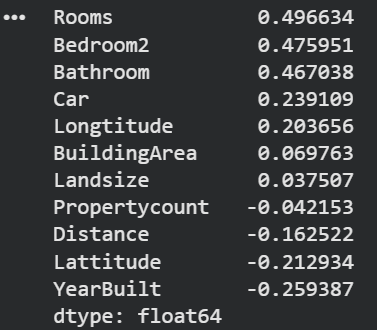

#Normalization

In [4]:
# Identify numerical columns (excluding any dummy columns if we added them)
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[num_features])
X_scaled = pd.DataFrame(X_scaled, columns=num_features)

Train‑Test Split


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (10864, 11), Test size: (2716, 11)


# Train Linear Regression Model(main function for the task)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluation Metrics: it will give you the output of MAE, MSE, RMSE, R²
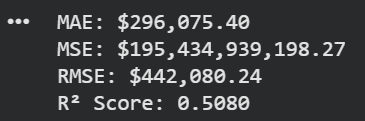

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"MSE: ${mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE: $296,075.40
MSE: $195,434,939,198.27
RMSE: $442,080.24
R² Score: 0.5080


Loss Curve (Residual Plot)

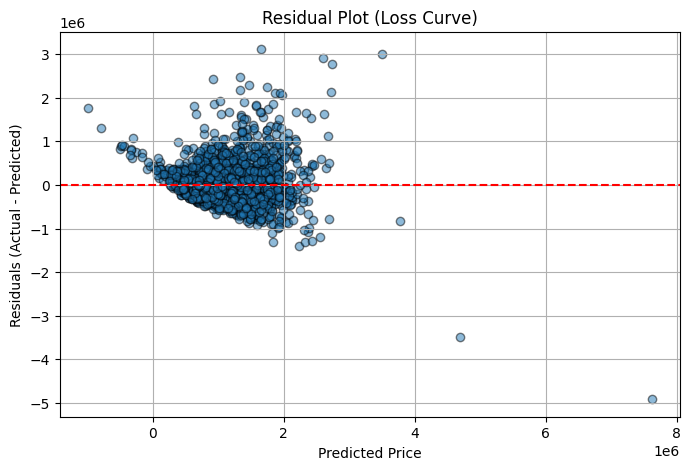

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Loss Curve)')
plt.grid(True)
plt.show()

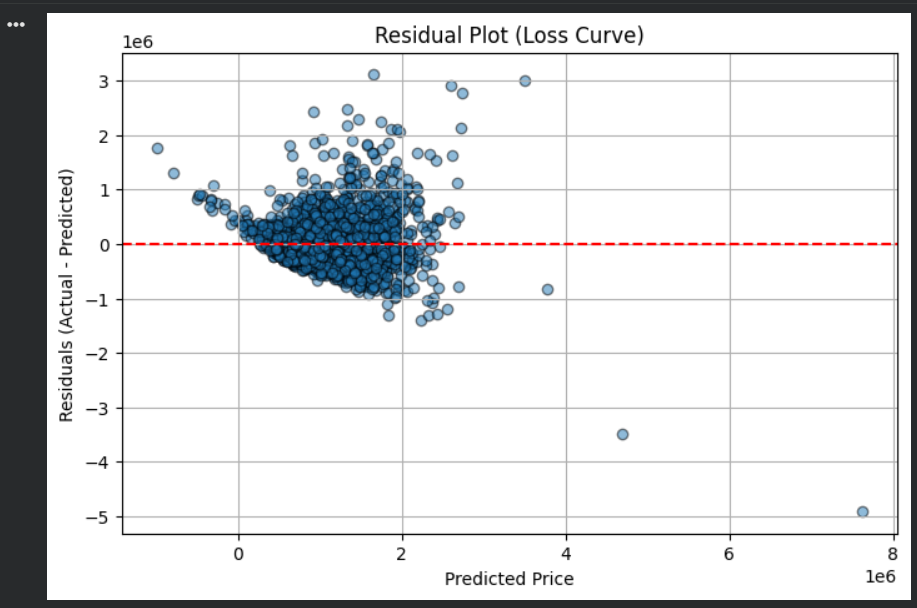

Sample Predictions: I have taken the first 10 rows

In [9]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head(10))

          Actual     Predicted
1061   2600000.0  1.388201e+06
6482    620000.0  7.933306e+05
8395   1000000.0  1.265211e+06
4659    430000.0  7.826278e+05
7386    392250.0  6.904614e+05
6607    700000.0  9.932172e+05
8094    439000.0  4.890929e+05
4590   2236000.0  1.786405e+06
13475   671000.0  5.610497e+05
10318  1870000.0  1.158529e+06


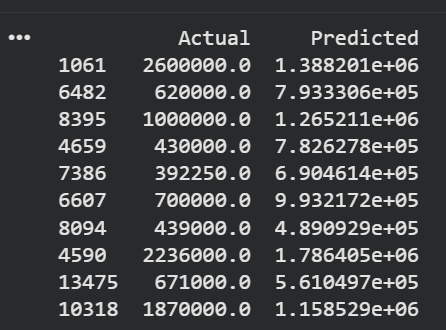

Improving Model Performance by adding categorical features,removing highly correlated features,use regularisation and handling outliers

In [10]:
# Include categoricals
cat_features = ['Type', 'Regionname']
X_full = df[['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
             'BuildingArea', 'YearBuilt', 'Distance', 'Lattitude',
             'Longtitude', 'Propertycount'] + cat_features]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', LinearRegression())])

X_train_full, X_test_full, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)
pipeline.fit(X_train_full, y_train)
y_pred_improved = pipeline.predict(X_test_full)

# Evaluate again
print(f"Improved R²: {r2_score(y_test, y_pred_improved):.4f}")

Improved R²: 0.6048


The improved R^2 is now 0.6048